<a href="https://colab.research.google.com/github/dg6r/coursera/blob/master/CondensingWithoutFreezing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install pyXSteam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 2.0 MB/s eta 0:00:00


Расход 12 кг/ч: выходная температура = nan °C, конденсат = 864.00 кг/ч


Расход 26 кг/ч: выходная температура = nan °C, конденсат = 1612.24 кг/ч


Расход 51 кг/ч: выходная температура = nan °C, конденсат = 1677.83 кг/ч


Расход 90 кг/ч: выходная температура = nan °C, конденсат = 1780.15 кг/ч


Расход 153 кг/ч: выходная температура = nan °C, конденсат = 1945.42 кг/ч


Text(0, 0.5, 'Температура, °C')

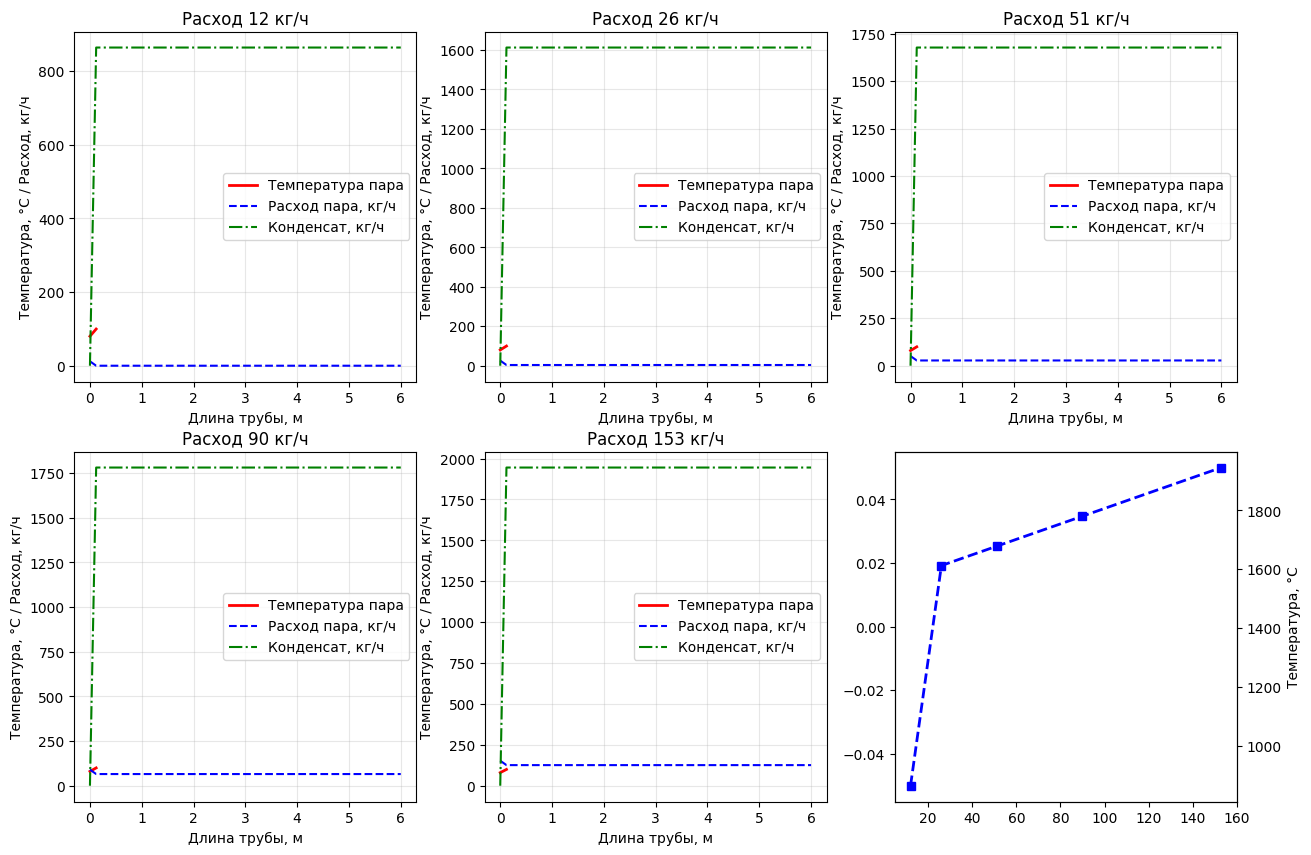

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pyXSteam.XSteam import XSteam
import math

# Инициализация таблицы свойств пара
steam = XSteam(XSteam.UNIT_SYSTEM_MKS)

# Параметры задачи
T_initial = 80      # начальная температура пара, °C
T_ambient = -40     # температура окружающей среды, °C
L = 6               # длина трубы, м
D = 0.08           # диаметр трубы, м (80 мм)
t_wall = 0.002     # толщина стенки, м (2 мм)
k_steel = 16       # теплопроводность нержавеющей стали, Вт/(м·К)
P_system = 1       # давление в системе, бар (можно уточнить)

# Расходы пара, кг/ч
mass_flows = [12, 26, 51, 90, 153]

def calculate_with_condensation(m_dot_kg_h, T_in, T_amb, L, D, t_wall, k_steel, P):
    # Переводим расход в кг/с
    m_dot = m_dot_kg_h / 3600

    # Внутренний диаметр
    D_inner = D - 2 * t_wall
    A_cross = math.pi * D_inner**2 / 4

    # Разбиваем трубу на 50 сегментов для точности
    n_segments = 50
    dx = L / n_segments
    x = np.linspace(0, L, n_segments + 1)

    # Массивы для хранения результатов
    T = np.zeros(n_segments + 1)  # температура пара
    m_steam = np.zeros(n_segments + 1)  # массовый расход пара
    m_cond = np.zeros(n_segments + 1)  # накопленная масса конденсата
    h = np.zeros(n_segments + 1)   # энтальпия

    # Начальные условия
    T[0] = T_in
    m_steam[0] = m_dot
    m_cond[0] = 0
    h[0] = steam.h_pt(P, T_in)

    for i in range(n_segments):
        # Текущие параметры
        T_current = T[i]
        m_current = m_steam[i]

        # Свойства пара на входе в сегмент
        rho_steam = steam.rho_pt(P, T_current)
        Cp_steam = steam.Cp_pt(P, T_current)
        mu_steam = steam.my_pt(P, T_current)
        k_steam = steam.tc_pt(P, T_current)

        # Скорость потока
        v = m_current / (rho_steam * A_cross)

        # Число Рейнольдса
        Re = rho_steam * v * D_inner / mu_steam

        # Число Нуссельта
        if Re < 2300:
            Nu = 4.36
        else:
            Pr = 1.0  # упрощённо
            Nu = 0.023 * Re**0.8 * Pr**0.4

        # Коэффициенты теплообмена
        h_inner = Nu * k_steam / D_inner
        h_outer = 25  # Вт/(м²·К) — естественная конвекция

        # Общее термическое сопротивление
        R_total = (1 / (h_inner * math.pi * D_inner) +
                  math.log(D / D_inner) / (2 * math.pi * k_steel) +
                  1 / (h_outer * math.pi * D))
        U = 1 / R_total

        # Площадь теплообмена сегмента
        A_segment = math.pi * D * dx

        # Тепловой поток через стенку
        Q = U * A_segment * (T_current - T_amb)

        # Охлаждение пара без конденсации (предварительная оценка)
        delta_T_no_cond = Q / (m_current * Cp_steam)
        T_predicted = T_current - delta_T_no_cond

        # Проверяем, происходит ли конденсация
        T_sat = steam.tsat_p(P)  # температура насыщения при данном давлении

        if T_predicted < T_sat:
            # Происходит конденсация
            # Теплота конденсации
            h_fg = steam.hV_p(P) - steam.hL_p(P)

            # Количество тепла для охлаждения до T_sat
            Q_to_sat = m_current * Cp_steam * (T_current - T_sat)

            if Q <= Q_to_sat:
                # Конденсации нет, просто охлаждение
                T[i+1] = T_current - Q / (m_current * Cp_steam)
                m_steam[i+1] = m_current
                m_cond[i+1] = m_cond[i]
            else:
                # Происходит конденсация
                Q_cond = Q - Q_to_sat
                m_condensed = Q_cond / h_fg

                # Ограничиваем конденсат доступным количеством пара
                if m_condensed > m_current:
                    m_condensed = m_current


                T[i+1] = T_sat  # после конденсации температура = T_sat
                m_steam[i+1] = m_current - m_condensed
                m_cond[i+1] = m_cond[i] + m_condensed * 3600 * dx / L  # переводим в кг/ч на метр
        else:
            # Конденсации нет
            T[i+1] = T_predicted
            m_steam[i+1] = m_current
            m_cond[i+1] = m_cond[i]

    return x, T, m_steam * 3600, m_cond * 3600  # возвращаем в кг/ч

# Расчёт для всех расходов
results = {}

plt.figure(figsize=(15, 10))

for idx, m_flow in enumerate(mass_flows):
    x, T, m_steam, m_cond = calculate_with_condensation(
        m_flow, T_initial, T_ambient, L, D, t_wall, k_steel, P_system
    )
    results[m_flow] = {'x': x, 'T': T, 'm_steam': m_steam, 'm_cond': m_cond}

    plt.subplot(2, 3, idx + 1)
    plt.plot(x, T, 'r-', linewidth=2, label='Температура пара')
    plt.plot(x, m_steam, 'b--', linewidth=1.5, label='Расход пара, кг/ч')
    plt.plot(x, m_cond, 'g-.', linewidth=1.5, label='Конденсат, кг/ч')
    plt.xlabel('Длина трубы, м')
    plt.ylabel('Температура, °C / Расход, кг/ч')
    plt.title(f'Расход {m_flow} кг/ч')
    plt.legend()
    plt.grid(True, alpha=0.3)
    print(f"Расход {m_flow} кг/ч: выходная температура = {T[-1]:.2f} °C, "
          f"конденсат = {m_cond[-1]:.2f} кг/ч")

# Общий график температур на выходе
plt.subplot(2, 3, 6)
outlet_temps = [results[m]['T'][-1] for m in mass_flows]
condensate_at_end = [results[m]['m_cond'][-1] for m in mass_flows]
plt.plot(mass_flows, outlet_temps, 'ro-', linewidth=2, markersize=8, label='Температура на выходе')
plt.twinx()
plt.plot(mass_flows, condensate_at_end, 'bs--', linewidth=2, markersize=6, label='Конденсат на выходе')
plt.xlabel('Расход пара, кг/ч')
plt.ylabel('Температура, °C')

